# Watching the Kirkwood Gaps Form

#### This tutorial starts from a smooth, gap-free asteroid belt, lets Jupiter and Saturn act on it for a million years, and animates the gaps opening — then compares the result with the real belt from MPC data.

The [Kirkwood gaps tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/) showed *where* the gaps are: sharp deficits in the distribution of semi-major axes at the 4:1, 3:1, 5:2, 7:3 and 2:1 mean-motion resonances with Jupiter. This one is about *how they got there*. The mechanism was found by [Wisdom (1983)](https://ui.adsabs.harvard.edu/abs/1983Icar...56...51W): an asteroid in one of these resonances does not sit still. Its eccentricity wanders chaotically, and every so often it jumps high enough that the orbit crosses Mars's or Earth's — after which a close encounter with a planet removes the asteroid from the belt for good. The resonance does not clear a lane in semi-major axis; it pumps eccentricity until the inner planets do the clearing.

That is a story about *time*, so it wants an animation. We:

1. take the real belt's semi-major-axis distribution from `MPCORB.DAT` as the answer we are trying to reproduce;
2. build a **synthetic belt** of test particles with no gaps at all, spread uniformly between 2.0 and 3.5 AU on nearly circular orbits;
3. integrate them with **REBOUND**'s symplectic `WHFast` integrator under the Sun, Jupiter and Saturn for a million years — splitting the particles across CPU cores, which is legitimate because test particles do not interact;
4. **mark particles as removed** once their orbits cross Mars's, standing in for the planetary encounter that would eject them, and freeze them in the plots at the point where they crossed;
5. **animate** the belt in the (semi-major axis, eccentricity) plane alongside its evolving histogram, with the real belt underneath for comparison, and render it as video for the web.

The result is honest about what a million years can and cannot do: the 3:1 and 5:2 gaps open in front of you, the inner edge is eaten away by the ν₆ secular resonance, and the 2:1 and 7:3 gaps do not appear at all — they take tens of millions of years, and understanding them took another decade of research.

This notebook builds on the [Kirkwood gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/) and [N-body simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/) tutorials in the [Working with Orbits](https://docs.minorplanetcenter.net/tutorials/orbit_tutorials/) section, and on the animation techniques of the [minimoon animation tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_animation_minimoons/).

## Environment Setup

This notebook requires `rebound`, `matplotlib`, `numpy`, and `requests`, plus the `ffmpeg` command-line tool to write MP4 files. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy requests ipykernel
conda install -c conda-forge ffmpeg          # for MP4 output (GIFs need only Pillow, which matplotlib brings in)

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion tutorials, you can simply reuse it.

**Runtime note:** Step 3 integrates a few thousand test particles for a million years. On a laptop with eight cores that takes about a quarter of an hour; the result is cached to disk so the animation can be re-rendered without repeating it.

# Install and Import Packages

In [1]:
import os
import gzip
import time
import base64
import collections
import multiprocessing
import warnings
from pathlib import Path

import requests
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import HTML

import rebound

# Step 1: The Real Belt, from MPCORB

The target: the semi-major-axis distribution of the known asteroids. We download and parse [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html) exactly as in the Kirkwood tutorial (only the semi-major axis and the epoch code are needed here), keep the orbits at the common epoch, and histogram them. Jupiter's semi-major axis, which sets the resonance locations through Kepler's third law, comes from the same REBOUND/Horizons query we will use for the simulation.

**Download note:** the cell caches `MPCORB.DAT.gz` (about 90 MB) in the notebook's working directory and only downloads it if it is not already present.

In [2]:
MPCORB_URL = "https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT.gz"
MPCORB_FILE = "MPCORB.DAT.gz"

if not os.path.exists(MPCORB_FILE):
    print(f"Downloading {MPCORB_URL} (about 90 MB; this may take a few minutes)")
    with requests.get(MPCORB_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(MPCORB_FILE + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(MPCORB_FILE + ".part", MPCORB_FILE)
    print("  done")
else:
    print(f"Using cached {MPCORB_FILE}")

# Fixed-width columns (1-indexed): epoch 21-25 (packed), e 71-79, a 93-103
rows = []
with gzip.open(MPCORB_FILE, "rt") as f:
    in_header = True
    for line in f:
        if in_header:
            if line.startswith("----------"):
                in_header = False
            continue
        if len(line) < 104:
            continue
        try:
            rows.append((float(line[92:103]), float(line[70:79]), line[20:25]))
        except ValueError:
            continue
epoch_mode = collections.Counter(r[2] for r in rows).most_common(1)[0][0]
real = np.array([(a, e) for a, e, ep in rows if ep == epoch_mode and 1.5 < a < 4.5 and e < 1])
a_real, e_real = real[:, 0], real[:, 1]
print(f"{len(a_real):,} real orbits with 1.5 < a < 4.5 AU at the common epoch {epoch_mode!r}")

# Sun, Jupiter and Saturn from JPL Horizons at the catalogue epoch; this is also the simulation's planetary system
def unpack_epoch(packed):
    century = {"I": 18, "J": 19, "K": 20}[packed[0]]
    year = century * 100 + int(packed[1:3])
    month = int(packed[3], 36) if packed[3].isdigit() else ord(packed[3]) - 55
    day = int(packed[4], 36) if packed[4].isdigit() else ord(packed[4]) - 55
    return f"{year:04d}-{month:02d}-{day:02d}"

epoch_date = unpack_epoch(epoch_mode)
planets_sim = rebound.Simulation()
planets_sim.units = ("AU", "yr", "Msun")
for body in ["Sun", "Jupiter", "Saturn"]:
    planets_sim.add(body, date=f"{epoch_date} 00:00")
a_jup = planets_sim.particles[1].orbit(primary=planets_sim.particles[0]).a
RESONANCES = {"4:1": 4, "3:1": 3, "5:2": 2.5, "7:3": 7 / 3, "2:1": 2}
a_res = {name: a_jup * ratio ** (-2 / 3) for name, ratio in RESONANCES.items()}
print(f"Jupiter: a = {a_jup:.3f} AU; resonances at " + ", ".join(f"{k} {v:.2f}" for k, v in a_res.items()))

Using cached MPCORB.DAT.gz


1,511,155 real orbits with 1.5 < a < 4.5 AU at the common epoch 'K2669'
Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Searching NASA Horizons for 'Jupiter'... 


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 


Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Jupiter: a = 5.203 AU; resonances at 4:1 2.06, 3:1 2.50, 5:2 2.82, 7:3 2.96, 2:1 3.28


# Step 2: A Synthetic Belt with No Gaps

Now the initial conditions for the experiment: `N_PARTICLES` massless test particles spread **uniformly** in semi-major axis from 2.0 to 3.5 AU, with small eccentricities (0–0.15) and inclinations (0–10°) and random orbital angles. Nothing about this distribution knows where the resonances are; any structure that appears later is Jupiter's doing.

A few parameters control the cost of the experiment. The integration span `T_END` and the output cadence `DT_OUT` set the number of snapshots (and so the animation's frames); the time step `DT` must be a small fraction of the shortest orbital period (about 2.8 years at 2 AU); and `N_PROC` is the number of CPU cores to spread the particles over.

In [3]:
N_PARTICLES = 4000            # test particles in the synthetic belt
A_MIN, A_MAX = 2.0, 3.5       # AU
E_MAX, I_MAX_DEG = 0.15, 10.0
T_END = 1.0e6                 # years
DT_OUT = 2000.0               # years between snapshots (500 snapshots = 500 animation frames)
DT = 0.08                     # WHFast time step in years (~35 steps per orbit at 2 AU)
N_PROC = max(1, min(8, (os.cpu_count() or 2) - 2))
SIM_CACHE = "kirkwood_gaps_sim.npz"

# The planetary system, as plain numbers so that it can be handed to worker processes
PLANETS = [(p.m, p.x, p.y, p.z, p.vx, p.vy, p.vz) for p in planets_sim.particles]
print(f"{N_PARTICLES} particles, {T_END/1e6:.1f} Myr, {int(T_END / DT_OUT) + 1} snapshots, {N_PROC} processes")

4000 particles, 1.0 Myr, 501 snapshots, 8 processes


# Step 3: Integrate with WHFast, in Parallel

`WHFast` ([Rein & Tamayo 2015](https://ui.adsabs.harvard.edu/abs/2015MNRAS.452..376R)) is REBOUND's symplectic Wisdom–Holman integrator: fast, and with the long-term energy behaviour that a million-year run needs. Three details of its use here:

- **Test particles.** Setting `sim.N_active = 3` tells REBOUND that only the Sun, Jupiter and Saturn have mass; the belt particles feel them but not each other, so the cost grows linearly with the number of particles rather than quadratically.
- **`safe_mode = 0`.** By default WHFast converts between coordinate systems every step so that positions are always readable; switching that off roughly doubles the speed, at the price of calling `sim.synchronize()` before reading positions at each snapshot.
- **Vectorized elements.** Calling `particle.orbit()` two thousand times per snapshot is slow in Python; the semi-major axis and eccentricity follow from the heliocentric position and velocity in a few lines of `numpy` (the vis-viva equation for `a`, the angular momentum for `e`).

Because the particles are independent, `run_chunk` integrates any subset of them, and the driver spreads `N_PARTICLES` over `N_PROC` worker processes with `multiprocessing`. The workers are started with the `fork` method, which lets them see the functions defined in this notebook (it is the default on Linux and works on macOS; on Windows the cell falls back to running the chunks one after another). The result — semi-major axis and eccentricity of every particle at every snapshot — is cached in `kirkwood_gaps_sim.npz`, so delete that file if you change the parameters.

In [4]:
def run_chunk(args):
    seed, n = args
    # a few removed particles end up on tiny or hyperbolic orbits, where WHFast warns about its step; harmless here
    warnings.filterwarnings("ignore", message=".*WHFast convergence.*")
    sim = rebound.Simulation()
    sim.units = ("AU", "yr", "Msun")
    for m, x, y, z, vx, vy, vz in PLANETS:
        sim.add(m=m, x=x, y=y, z=z, vx=vx, vy=vy, vz=vz)
    sim.move_to_com()
    sim.N_active = len(PLANETS)                       # everything added from here on is a test particle
    rng = np.random.default_rng(seed)
    a0, e0 = rng.uniform(A_MIN, A_MAX, n), rng.uniform(0.0, E_MAX, n)
    for k in range(n):
        sim.add(primary=sim.particles[0], a=a0[k], e=e0[k], inc=np.radians(rng.uniform(0, I_MAX_DEG)),
                Omega=rng.uniform(0, 2 * np.pi), omega=rng.uniform(0, 2 * np.pi), f=rng.uniform(0, 2 * np.pi))
    sim.integrator = "whfast"
    sim.dt = DT
    sim.ri_whfast.safe_mode = 0

    times = np.arange(0.0, T_END + 1e-6, DT_OUT)
    a_hist, e_hist = np.empty((len(times), n)), np.empty((len(times), n))
    n_planets = len(PLANETS)
    for j, t in enumerate(times):
        sim.integrate(t)
        sim.synchronize()                   # needed with safe_mode = 0 before reading positions
        p = sim.particles
        s = p[0]
        r_vec = np.array([[q.x - s.x, q.y - s.y, q.z - s.z] for q in p[n_planets:]])
        v_vec = np.array([[q.vx - s.vx, q.vy - s.vy, q.vz - s.vz] for q in p[n_planets:]])
        GM = sim.G * s.m
        r, v2 = np.linalg.norm(r_vec, axis=1), np.sum(v_vec * v_vec, axis=1)
        a = 1.0 / (2.0 / r - v2 / GM)                  # vis-viva
        h2 = np.sum(np.cross(r_vec, v_vec) ** 2, axis=1)
        a_hist[j], e_hist[j] = a, np.sqrt(np.maximum(0.0, 1.0 - h2 / (GM * a)))
    return times, a_hist, e_hist

def run_parallel(n_total, n_proc):
    sizes = [n_total // n_proc + (1 if k < n_total % n_proc else 0) for k in range(n_proc)]
    jobs = [(1000 + k, sizes[k]) for k in range(n_proc)]
    try:
        with multiprocessing.get_context("fork").Pool(n_proc) as pool:
            results = pool.map(run_chunk, jobs)
    except ValueError:                                 # no fork on this platform: run serially
        print("fork start method unavailable; running the chunks one after another")
        results = [run_chunk(job) for job in jobs]
    times = results[0][0]
    return times, np.concatenate([r[1] for r in results], axis=1), np.concatenate([r[2] for r in results], axis=1)

if os.path.exists(SIM_CACHE):
    cache = np.load(SIM_CACHE)
    times, a_sim, e_sim = cache["times"], cache["a"], cache["e"]
    print(f"Loaded cached simulation: {a_sim.shape[1]} particles, {len(times)} snapshots")
else:
    tic = time.time()
    times, a_sim, e_sim = run_parallel(N_PARTICLES, N_PROC)
    np.savez_compressed(SIM_CACHE, times=times, a=a_sim, e=e_sim)
    print(f"Integrated {a_sim.shape[1]} particles for {times[-1]/1e6:.1f} Myr in {(time.time() - tic)/60:.1f} min "
          f"on {N_PROC} processes; cached to {SIM_CACHE}")

Integrated 4000 particles for 1.0 Myr in 11.9 min on 8 processes; cached to kirkwood_gaps_sim.npz


# Step 4: Removing the Planet-Crossers

The simulation contains only the Sun, Jupiter and Saturn, so a particle whose eccentricity has been pumped up merely *crosses* the inner planets' orbits; nothing ever removes it. In the real Solar System a Mars-crossing asteroid is scattered within a few million to a few tens of millions of years, and an Earth-crosser within a few million ([Gladman et al. 1997](https://ui.adsabs.harvard.edu/abs/1997Sci...277..197G)). We stand in for that step with a simple rule: a particle counts as **removed from the belt** from the first snapshot at which its perihelion `q = a (1 − e)` falls inside Mars's aphelion distance, 1.67 AU, and in the plots it stays frozen, in grey, at the point where that happened. This compresses the real removal step to zero time, which is why the gaps here open faster than they would in nature — but the *pattern* of what is removed, and where, is the physics we are after.

The two panels below show the belt at the start and at the end of the run in the (a, e) plane, with the resonances marked and the Mars-crossing line drawn. Then the histogram of survivors is compared with the real belt.

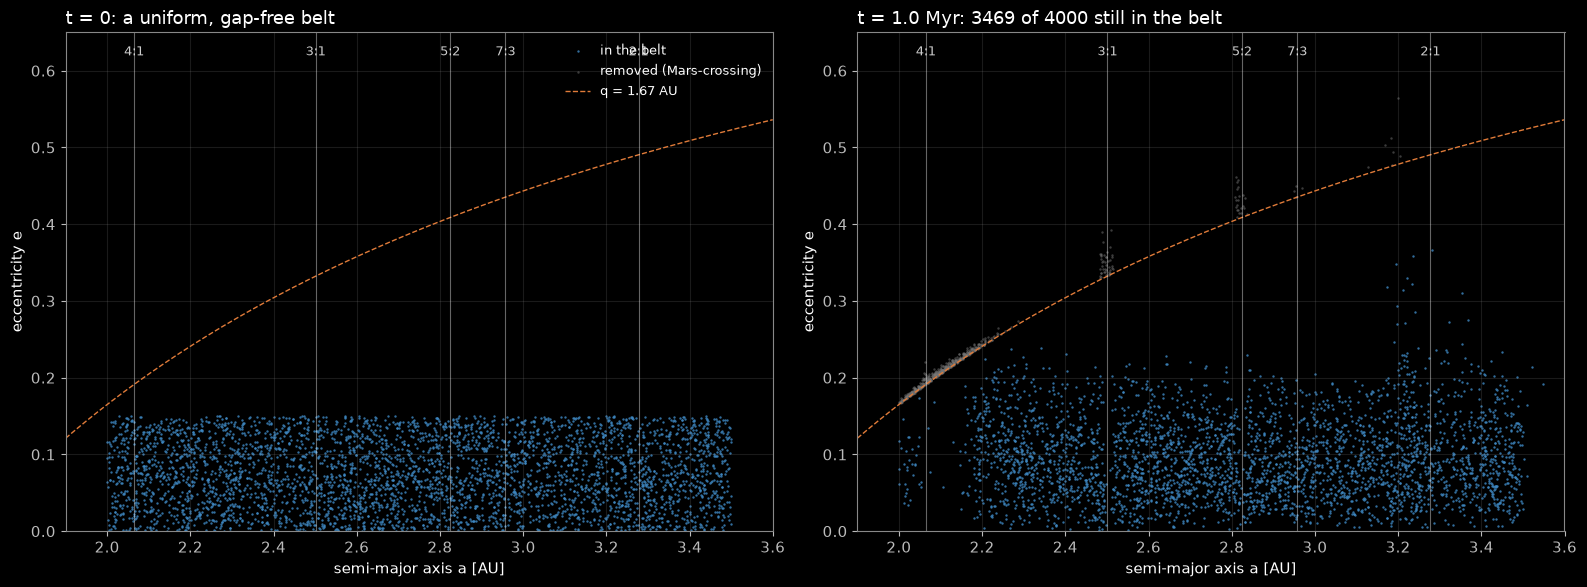

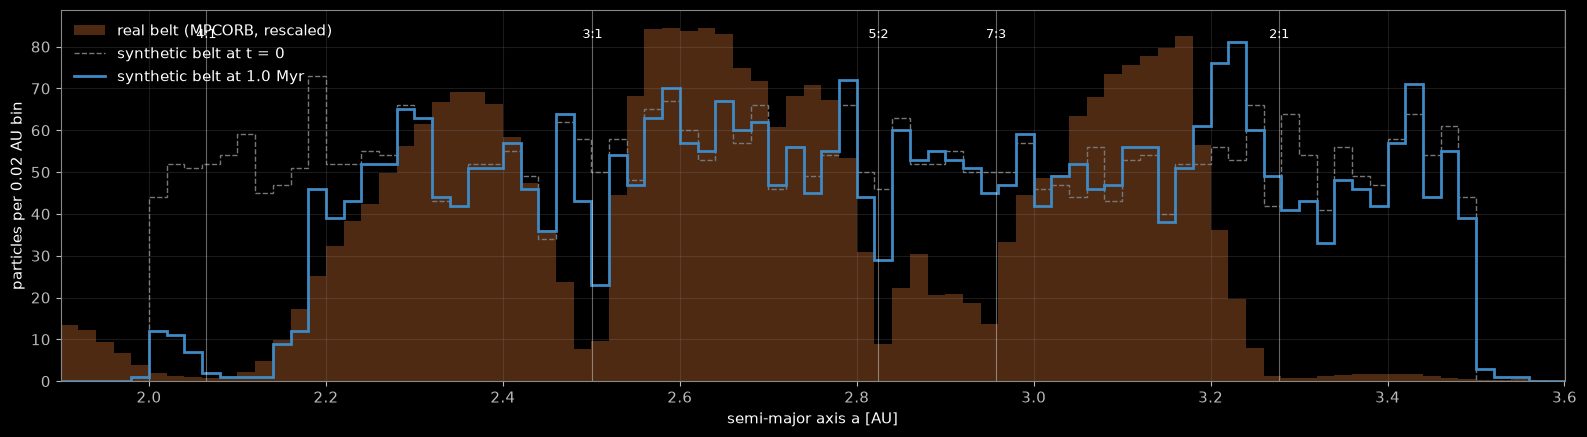

In [5]:
Q_MARS = 1.67                                       # AU: aphelion of Mars, the removal threshold
q_sim = a_sim * (1 - e_sim)
crossed = np.cumsum(q_sim < Q_MARS, axis=0) > 0    # True from the first Mars-crossing snapshot onward
alive = ~crossed
n_alive = alive.sum(axis=1)

# For plotting, freeze each removed particle at the snapshot where it crossed: what the simulation does with it
# afterwards (some are eventually thrown onto hyperbolic orbits by Jupiter) is no longer part of the belt's story.
first_cross = np.where(crossed.any(axis=0), crossed.argmax(axis=0), len(times) - 1)
frozen = np.minimum(np.arange(len(times))[:, None], first_cross[None, :])
a_plot, e_plot = np.take_along_axis(a_sim, frozen, axis=0), np.take_along_axis(e_sim, frozen, axis=0)

BINS = np.arange(1.9, 3.6, 0.02)
def survivor_hist(j):
    return np.histogram(a_sim[j][alive[j]], bins=BINS)[0]
hist_real = np.histogram(a_real, bins=BINS)[0]
scale = survivor_hist(0).mean() / hist_real[(BINS[:-1] > 2.1) & (BINS[:-1] < 3.3)].mean()

plt.rcParams.update({"figure.facecolor": "black", "axes.facecolor": "black", "savefig.facecolor": "black",
                     "text.color": "white", "axes.labelcolor": "white", "xtick.color": "#bbbbbb",
                     "ytick.color": "#bbbbbb", "axes.edgecolor": "#888888", "font.size": 11})
BLUE, ORANGE, GREY = "#3f89c4", "#e07b39", "#777777"

def draw_ae_axes(ax, j, title):
    ax.scatter(a_plot[j][alive[j]], e_plot[j][alive[j]], s=3, color=BLUE, alpha=0.8, lw=0, label="in the belt")
    ax.scatter(a_plot[j][crossed[j]], e_plot[j][crossed[j]], s=3, color=GREY, alpha=0.5, lw=0, label="removed (Mars-crossing)")
    a_line = np.linspace(1.9, 3.6, 200)
    ax.plot(a_line, 1 - Q_MARS / a_line, color=ORANGE, lw=1, ls="--", label=f"q = {Q_MARS} AU")
    for name, a_r in a_res.items():
        ax.axvline(a_r, color="white", lw=0.8, alpha=0.4)
        ax.text(a_r, 0.62, name, ha="center", fontsize=9, color="white", alpha=0.8)
    ax.set_xlim(1.9, 3.6); ax.set_ylim(0, 0.65)
    ax.set_xlabel("semi-major axis a [AU]"); ax.set_ylabel("eccentricity e")
    ax.set_title(title, loc="left"); ax.grid(alpha=0.15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
draw_ae_axes(axes[0], 0, "t = 0: a uniform, gap-free belt")
draw_ae_axes(axes[1], len(times) - 1, f"t = {times[-1]/1e6:.1f} Myr: {n_alive[-1]} of {a_sim.shape[1]} still in the belt")
axes[0].legend(loc="upper right", framealpha=0, fontsize=9)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.stairs(hist_real * scale, BINS, fill=True, color=ORANGE, alpha=0.35, label="real belt (MPCORB, rescaled)")
ax.stairs(survivor_hist(0), BINS, color=GREY, lw=1, ls="--", label="synthetic belt at t = 0")
ax.stairs(survivor_hist(len(times) - 1), BINS, color=BLUE, lw=2, label=f"synthetic belt at {times[-1]/1e6:.1f} Myr")
for name, a_r in a_res.items():
    ax.axvline(a_r, color="white", lw=0.8, alpha=0.4); ax.text(a_r, ax.get_ylim()[1] * 0.95, name, ha="center", fontsize=9, va="top")
ax.set_xlim(1.9, 3.6); ax.set_xlabel("semi-major axis a [AU]"); ax.set_ylabel("particles per 0.02 AU bin")
ax.legend(loc="upper left", framealpha=0); ax.grid(alpha=0.15); plt.tight_layout(); plt.show()

### Reading the figures

In the (a, e) plane the resonances have become vertical plumes: particles at the 3:1 and 5:2 (and, more weakly, 7:3) locations have had their eccentricities pumped upward, and the ones that reached the dashed Mars-crossing line are greyed out. Away from the resonances nothing has happened — eccentricities have drifted a little under the planets' secular perturbations, but no particle has left. Near the inner edge, below about 2.1 AU, a broad band has also been cleared: that is the **ν₆ secular resonance**, where an asteroid's perihelion precesses at the same rate as Saturn's, which pumps eccentricity just as effectively as a mean-motion resonance and is what defines the belt's inner boundary.

In the histogram the 3:1 and 5:2 gaps have opened cleanly where the real belt has them, and the inner edge has moved outward toward the real one. The **2:1** gap has *not* opened, nor has the outer edge of the belt at 3.3 AU formed. That is not a failure of the simulation: the outer resonances work on timescales of tens to hundreds of millions of years and, for the 2:1, through a slower and more subtle mechanism (the overlap of secondary and secular resonances inside it — [Moons, Morbidelli & Migliorini 1998](https://ui.adsabs.harvard.edu/abs/1998Icar..135..458M)). A million years is enough to see Wisdom's mechanism at work, not to finish the job.

# Step 5: The Animation

Now the same two views as a movie: one frame for every second snapshot, four thousand years apart, so the million years pass in about twenty seconds. The left panel is the (a, e) plane — watch the resonant plumes rise and their tops turn grey as particles cross the Mars line — and the right panel is the histogram of survivors with the real belt underneath. The pattern is the one from the minimoon animation tutorial: create every artist once, update them in `draw`, and save with `FFMpegWriter` and `PillowWriter`. (A scatter of thousands of moving points compresses poorly, so this video uses a lower frame rate and a slightly higher compression setting than the minimoon ones.)

Two small tricks are specific to this animation. A scatter plot's points are moved with `set_offsets` and recoloured with `set_facecolors`, so a single scatter artist serves for both the surviving and the removed particles; and the histogram is a `stairs` artist whose heights are replaced with `set_data`, which is far cheaper than redrawing bars.

In [6]:
def make_kirkwood_animation(fps=12, every=2):
    frames = np.arange(0, len(times), every)                 # every second snapshot: ~20 s at 12 fps
    colors = np.empty((a_sim.shape[1], 4))
    fig = plt.figure(figsize=(14.4, 6.4), dpi=100)
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.2, left=0.05, right=0.98, top=0.85, bottom=0.13)
    ax, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    fig.suptitle("How the Kirkwood gaps form: a gap-free belt under Jupiter and Saturn", fontsize=16, fontweight="bold", y=0.96)
    fig.text(0.05, 0.895, f"{a_sim.shape[1]} test particles, REBOUND WHFast; particles are removed once they cross Mars's orbit (q < {Q_MARS} AU)",
             fontsize=10, color="#bbbbbb")

    # left: (a, e) plane
    scat = ax.scatter(a_plot[0], e_plot[0], s=3, lw=0)
    a_line = np.linspace(1.9, 3.6, 200)
    ax.plot(a_line, 1 - Q_MARS / a_line, color=ORANGE, lw=1, ls="--")
    ax.text(3.55, 1 - Q_MARS / 3.55 + 0.02, "Mars-crossing", ha="right", color=ORANGE, fontsize=9)
    for name, a_r in a_res.items():
        ax.axvline(a_r, color="white", lw=0.8, alpha=0.4); ax.text(a_r, 0.62, name, ha="center", fontsize=9, alpha=0.8)
    ax.set_xlim(1.9, 3.6); ax.set_ylim(0, 0.65); ax.grid(alpha=0.15)
    ax.set_xlabel("semi-major axis a [AU]"); ax.set_ylabel("eccentricity e")
    time_txt = ax.text(0.02, 0.95, "", transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")
    count_txt = ax.text(0.02, 0.87, "", transform=ax.transAxes, fontsize=11, va="top", color="#bbbbbb")

    # right: histogram of survivors against the real belt
    ax2.stairs(hist_real * scale, BINS, fill=True, color=ORANGE, alpha=0.35, label="real belt (MPCORB, rescaled)")
    hist_artist = ax2.stairs(survivor_hist(0), BINS, color=BLUE, lw=2, label="synthetic belt, survivors")
    ymax = survivor_hist(0).max() * 1.35
    for name, a_r in a_res.items():
        ax2.axvline(a_r, color="white", lw=0.8, alpha=0.4); ax2.text(a_r, ymax * 0.97, name, ha="center", fontsize=9, va="top")
    ax2.set_xlim(1.9, 3.6); ax2.set_ylim(0, ymax); ax2.grid(alpha=0.15)
    ax2.set_xlabel("semi-major axis a [AU]"); ax2.set_ylabel("particles per 0.02 AU bin")
    ax2.legend(loc="upper left", framealpha=0, fontsize=9)

    def draw(k):
        j = frames[k]
        scat.set_offsets(np.column_stack([a_plot[j], e_plot[j]]))
        colors[alive[j]] = (0.247, 0.537, 0.769, 0.85)           # BLUE
        colors[crossed[j]] = (0.47, 0.47, 0.47, 0.35)            # GREY
        scat.set_facecolors(colors)
        hist_artist.set_data(survivor_hist(j))
        time_txt.set_text(f"t = {times[j]/1e6:4.2f} Myr")
        count_txt.set_text(f"{n_alive[j]} in the belt, {a_sim.shape[1] - n_alive[j]} removed")
        return scat, hist_artist, time_txt, count_txt

    return fig, FuncAnimation(fig, draw, frames=len(frames), interval=1000 / fps, blit=False)

OUT_DIR = Path("../animations")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_animation(fig, anim, stem, fps=12, gif_fps=12, gif_dpi=50):
    stem = OUT_DIR / stem
    tic = time.time()
    anim.save(f"{stem}.mp4", writer=FFMpegWriter(fps=fps, codec="h264", bitrate=-1,
                                                 extra_args=["-pix_fmt", "yuv420p", "-crf", "27"]), dpi=100)
    anim.save(f"{stem}.gif", writer=PillowWriter(fps=gif_fps), dpi=gif_dpi)
    fig.savefig(f"{stem}.png", dpi=100)
    sizes = {ext: os.path.getsize(f"{stem}.{ext}") / 1e6 for ext in ("mp4", "gif", "png")}
    print(f"{stem.name}: mp4 {sizes['mp4']:.1f} MB, gif {sizes['gif']:.1f} MB, png {sizes['png']:.2f} MB ({time.time() - tic:.0f} s)")
    return stem

def show_video(stem, width=960):
    data = base64.b64encode(Path(f"{stem}.mp4").read_bytes()).decode()
    return HTML(f'<video controls loop muted playsinline width="{width}" src="data:video/mp4;base64,{data}"></video>')

fig, anim = make_kirkwood_animation()
stem = save_animation(fig, anim, "kirkwood_gaps_forming")
plt.close(fig)
show_video(stem)

kirkwood_gaps_forming: mp4 3.8 MB, gif 6.6 MB, png 0.17 MB (81 s)


# Summary

In this tutorial we:

1. **Took the real belt's** semi-major-axis distribution from `MPCORB.DAT` as the target, with the resonance locations from Jupiter's orbit
2. **Built a gap-free synthetic belt** of test particles, uniform in semi-major axis with small eccentricities and inclinations
3. **Integrated it for a million years** with REBOUND's `WHFast`, using `N_active` for test particles, `safe_mode = 0` for speed, a vectorized element readout, and `multiprocessing` to spread the particles over the CPU cores
4. **Removed Mars-crossers** as a stand-in for planetary encounters, and saw resonant eccentricity pumping — Wisdom's mechanism — carve the 3:1 and 5:2 gaps and the ν₆ inner edge, while the 2:1 gap and the outer edge stayed for another day
5. **Animated** the (a, e) plane and the histogram together, and rendered the result as MP4, GIF and a poster frame for the [animations page](https://docs.minorplanetcenter.net/tutorials/animation_tutorials/)

### Ideas to extend

- Run longer (10 Myr overnight) and watch the 7:3 gap deepen; the 2:1 needs more still
- Add Mars and Earth as massive bodies (with a smaller time step) and let REBOUND remove particles on real close encounters instead of the `q < 1.67 AU` rule
- Colour the particles by their *initial* semi-major axis to see how far the resonant ones wander before they leave
- Add the top-down "normalized belt" map from the Kirkwood tutorial as a third panel

### Further Resources

- [Wisdom (1983), *Chaotic behavior and the origin of the 3/1 Kirkwood gap*, Icarus 56, 51](https://ui.adsabs.harvard.edu/abs/1983Icar...56...51W)
- [Gladman et al. (1997), *Dynamical lifetimes of objects injected into asteroid belt resonances*, Science 277, 197](https://ui.adsabs.harvard.edu/abs/1997Sci...277..197G)
- [Moons, Morbidelli & Migliorini (1998), *Dynamical structure of the 2/1 commensurability with Jupiter and the origin of the resonant asteroids*, Icarus 135, 458](https://ui.adsabs.harvard.edu/abs/1998Icar..135..458M)
- [Rein & Tamayo (2015), *WHFast: a fast and unbiased implementation of a symplectic Wisdom-Holman integrator*, MNRAS 452, 376](https://ui.adsabs.harvard.edu/abs/2015MNRAS.452..376R)
- [REBOUND documentation: WHFast and test particles](https://rebound.readthedocs.io/)
- [Companion tutorial: The Kirkwood Gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/)
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)
- [Companion tutorial: Animating Minimoons](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_animation_minimoons/)
- [Working with Orbits](https://docs.minorplanetcenter.net/tutorials/orbit_tutorials/): the static tutorials this notebook builds on

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).